In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV,cross_validate,cross_val_predict
from sklearn.metrics import classification_report,confusion_matrix,make_scorer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# from util.client import Nba_Season, kelly, BNN_kelly, make_bets, pred_performance
from util.client import Nba_Season
from util.betting import kelly, BNN_kelly, make_bets, pred_performance
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.nn import PyroModule, PyroSample
import torch
import torch.nn as nn
from torch.nn import Softmax
from pyro.infer import MCMC, NUTS
from pyro.infer import Predictive

c:\Users\andre\OneDrive\Desktop\betting_bot\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Defining Utility Functions

In [3]:
# bet_shop_data_train = np.genfromtxt('../NBA/with_bets/2022-2023_season_all_ml.csv',delimiter=',')
# bet_shop_data_test = np.genfromtxt('../NBA/with_bets/2023-2024_season_all_ml.csv',delimiter=',')

def find_cap(bet_train_preds,test_preds,bet_shop_data_train,bet_shop_data_test,bet_samps_train,y_test,verbose=False,categorical=False,line_shopping=True):
    i = 0.01
    obs_tr = []
    obs_te = []
    ret_tr = []
    ret_te = []
    cap = []

    while i <= 0.9:
        obs_train,obs_test,ret_train,ret_test,obs_info,ret_info = make_bets(bet_train_preds,test_preds,bet_shop_data_train,bet_shop_data_test,bet_samps_train,y_test,diff_thresh=-0.05,
                                                        diff_cap=i,categorical=categorical,verbose=verbose,log_probs=True,line_shopping=line_shopping)
        
        obs_tr.append(obs_train)
        obs_te.append(obs_test)
        ret_tr.append(ret_train)
        ret_te.append(ret_test)
        cap.append(i)

        if verbose:
            if obs_test > 0:
                print(f'CAP (OBS): {i}')
                print(f'Train: {obs_train}, Test: {obs_test}')
            if ret_test > 0:
                print(f'CAP (RET): {i}')
                print(f'Train: {ret_train}, Test: {ret_test}')
        i += 0.01
    
    return cap, obs_tr, obs_te, ret_tr, ret_te

In [2]:
# import statements
import numpy as np
from bs4 import BeautifulSoup, Comment
from collections import defaultdict
import pandas as pd
from tqdm.auto import tqdm
import concurrent
import concurrent.futures
import pyro
from pyro.infer import Predictive
import torch
from sklearn.metrics import classification_report,confusion_matrix,make_scorer

def calc_implied(home_line,away_line,log_home,log_away):
    '''
    Shops for lines
    '''
    home_line_adj = home_line
    away_line_adj = away_line
    if home_line < 0:
        home_line_adj *= -1
        home_line_adj /= 100
        home_ratio = 1/(home_line_adj)
        implied_home = home_line_adj/(1+home_line_adj)
    else:
        home_line_adj /= 100
        home_ratio = home_line_adj
        implied_home = 1/(home_line+1)

    # calculate ratio and implied for away
    if away_line < 0:
        away_line_adj *= -1
        away_line_adj /= 100
        away_ratio = 1/(away_line_adj)
        implied_away = away_line_adj/(1+away_line_adj)
    else:
        away_line_adj /= 100
        away_ratio = away_line_adj
        implied_away = 1/(away_line_adj+1)
    
    diff_home = log_home - implied_home
    diff_away = log_away - implied_away

    return diff_home,home_ratio,diff_away,away_ratio

def kelly(home_pred,away_pred,home_lines,away_lines,max_bet=100,diff_thresh=0.05,diff_cap=0.25,log_probs=True):
    '''
    Applies kelly critereon based on features and moneyline data

    `home_pred`: Prediction from MLP for home team
    `away_pred`: Prediction from MLP for away team
    `home_lines`: List of moneylines for home team
    `away_lines`: List of moneylines for away team
    `diff_thresh`: Minimum difference between prediction and implied odds
    `diff_cap`: Maximum difference between prediciton and implied odds
    `log_probs`: Boolean flag to use log probabilities instead of raw
    '''
    bet_amount = 0
    to_win = 0

    if log_probs:
        log_home = (home_pred - (home_pred * away_pred)) / (home_pred + away_pred - (2*home_pred*away_pred))
        log_away = (away_pred - (home_pred * away_pred)) / (home_pred + away_pred - (2*home_pred*away_pred))
    else:
        log_home = home_pred
        log_away = away_pred

    max_diff = -float("inf")
    home_line = None
    away_line = None
    best_diff_home = -float("inf")
    best_diff_away = -float("inf")
    best_home_ratio = 0
    best_away_ratio = 0

    try:
        home_lines = [float(home_lines[0])]
        away_lines = [float(away_lines[0])]
        # use consesus pick to determine whether to bet on a game
        consesus_home = float(home_lines[-1])
        consesus_away = float(away_lines[-1])
    except:
        return 0,0,0

    diff_home,home_ratio,diff_away,away_ratio = calc_implied(consesus_home,consesus_away,log_home,log_away)

    prob = 0

    if diff_home > diff_away and diff_home > diff_thresh and diff_home < diff_cap:
        max_home = -float('inf')
        for i in range(len(home_lines)):
            if home_lines[i] > max_home: # choose line which maximizes return
                max_home = home_lines[i]
                home_line = home_lines[i]
                away_line = away_lines[i]

        best_diff_home,best_home_ratio,best_diff_away,best_away_ratio = calc_implied(home_line,away_line,log_home,log_away)
        kelly_home = log_home - (log_away/best_home_ratio)
        kelly_away = log_away - (log_home/best_away_ratio)

        bet_amount = (max_bet*kelly_home)
        if home_line < 0:
            to_win = bet_amount/((home_line*-1)/100)
        else:
            to_win = bet_amount/((home_line)/100)
        prob = home_pred

    
    elif diff_away > diff_home and diff_away > diff_thresh and diff_away < diff_cap:
        max_away = -float('inf')
        for i in range(len(away_lines)):
            if away_lines[i] > max_away: # choose line which maximizes return
                max_away = away_lines[i]
                home_line = home_lines[i]
                away_line = away_lines[i]

        best_diff_home,best_home_ratio,best_diff_away,best_away_ratio = calc_implied(home_line,away_line,log_home,log_away)
        kelly_home = log_home - (log_away/best_home_ratio)
        kelly_away = log_away - (log_home/best_away_ratio)

        bet_amount = (max_bet*kelly_away)
        if away_line < 0:
            to_win = bet_amount/((away_line*-1)/100)
        else:
            to_win = bet_amount/((away_line)/100)
        prob = away_pred

    return bet_amount,to_win,prob

def BNN_kelly(preds,actual,money_lines,one_hot=False,diff_thresh=0.05,diff_cap=0.25,log_probs=True,line_shopping=False):
    money_made = 0
    money_risked = 0
    correct = 0
    guessed = 0
    team_bet = []
    amount = []
    gained = []
    probs = []
    num_houses = (len(money_lines[0]) - 5) / 2 # number of lines to shop from 


    for i in range(len(preds)):
        if one_hot:
            away_pred = preds[i][0]
            home_pred = preds[i][1]
        else:
            home_pred = preds[i]
            away_pred = 1 - home_pred

        if line_shopping:
            # i=0 to i=4 game info, i=5 to end is betting
            away_lines = money_lines[i][5:int(5+num_houses)]
            home_lines = money_lines[i][int(5+num_houses):]
        else:
            away_lines = [money_lines[i][10]]
            home_lines = [money_lines[i][7]]

        to_bet,to_win,prob = kelly(home_pred,away_pred,home_lines,away_lines,diff_thresh=diff_thresh,diff_cap=diff_cap,log_probs=log_probs)
        probs.append(prob)
        money_risked += to_bet

        curr_gained = 0

        if to_win < 0:
            team_bet.append('Away')
            amount.append(to_bet)
            guessed += 1
            curr_gained = -1*to_bet
            if actual[i] == 1:
                correct += 1
                curr_gained = (-1*to_win)
                #money_made += curr_gained
        elif to_win > 0:
            team_bet.append('Home')
            amount.append(to_bet)
            guessed += 1
            curr_gained = -1*to_bet
            if actual[i] == 0:
                correct += 1
                curr_gained = to_win
                #money_made += curr_gained
        else:
            team_bet.append(0)
            amount.append(0)

        gained.append(curr_gained)

        if curr_gained > 0:
            money_made += curr_gained

    return correct,guessed,team_bet,probs,amount,gained

def pred_performance(train_preds: Predictive,test_preds: Predictive,y_train: torch.Tensor,
                     y_test: torch.Tensor,use_obs=True,use_ret=True,categorical=True):
    '''
    Prints confusion matrix and classification reports of a Predictive pyro object on training and test data, using "obs" and "_RETURN" flags

    `train_preds`: Tensor containing Pyro prediction object on training data
    `test_preds`: Tensor containing Pyro prediction object on test data
    `y_train`: Tensor containing outputs for x_train
    `y_test`: Tensor containingoutputs for x_test
    `use_obs`: Boolean flag to use the "obs" flag for predictive
    `use_ret`: Boolean flag to use the "_RETURN" flag for predictive
    `categorical`: Boolean flag to determine whether samples are categorical
    `log_probs`: Boolean flag to use log probabilities instead of raw
    '''

    y_train_1d = [0 if j[0] == 0 else 1 for j in y_train] # [0,1] -> home win -> 0 indicates home win, 1 indicates away
    y_test_1d = [0 if j[0] == 0 else 1 for j in y_test]

    if use_obs == False and use_ret == False:
        print('ERROR: set "use_obs" or "use_ret" to True')
        return

    print('---TRAINING SET---')

    if use_obs:
        if categorical:
            obs_preds = train_preds['obs'].float().mean(axis=1).float().mean(axis=0)
        else:
            obs_preds = train_preds['obs'].float().mean(axis=0)

        adj_train_preds = [0 if p[0] <= p[1] else 1 for p in obs_preds]
        print('OBS:')
        print('TN, FP, FN, TP')
        print(confusion_matrix(y_train_1d,adj_train_preds).ravel())
        print(classification_report(y_train_1d,adj_train_preds))

    if use_ret:
        ret_preds = train_preds['_RETURN'].float().mean(axis=0)
        adj_train_preds = [0 if p[0] <= p[1] else 1 for p in ret_preds]
        print('RET:')
        print('TN, FP, FN, TP')
        print(confusion_matrix(y_train_1d,adj_train_preds).ravel())
        print(classification_report(y_train_1d,adj_train_preds))

    print('---TEST SET---')

    if use_obs:
        if categorical:
            obs_preds = test_preds['obs'].float().mean(axis=1).float().mean(axis=0)
        else:
            obs_preds = test_preds['obs'].float().mean(axis=0)

        adj_test_preds = [0 if p[0] < p[1] else 1 for p in obs_preds]
        print('OBS:')
        print('TN, FP, FN, TP')
        print(confusion_matrix(y_test_1d,adj_test_preds).ravel())
        print(classification_report(y_test_1d,adj_test_preds))
    
    if use_ret:
        ret_preds = test_preds['_RETURN'].float().mean(axis=0)
        adj_test_preds = [0 if p[0] <= p[1] else 1 for p in ret_preds]
        print('RET:')
        print('TN, FP, FN, TP')
        print(confusion_matrix(y_test_1d,adj_test_preds).ravel())
        print(classification_report(y_test_1d,adj_test_preds))

def make_bets(train_preds,test_preds,bet_data_train,bet_data_test,bet_samps_train,
              bet_samps_test,use_obs=True,use_ret=True,diff_thresh=0.05,diff_cap=0.25,
              categorical=True,verbose=True,log_probs=True,line_shopping=False):
    
    '''
    Places bets using predictions made by a Pyro predictive object using the kelly critereon

    `train_preds`: Tensor containing Pyro prediction object on training data
    `test_preds`: Tensor containing Pyro prediction object on test data
    `bet_data_train`: Arraylike containing betting data for training
    `bet_data_test`: Arraylike containing betting data for testing
    `bet_samps_train`: Arraylike containing training samples
    `bet_samps_test`: Arraylike containing test samples
    `use_obs`: Boolean flag to use the "obs" flag for predictive
    `use_ret`: Boolean flag to use the "_RETURN" flag for predictive
    `diff_thresh`: Minimum difference between implied odds and predicted
    `diff_thresh`: Maximum difference between implied odds and predicted
    `categorical`: Boolean flag to determine whether samples are categorical
    `verbose`: Boolean flag to print bets
    `log_probs`: Boolean flag to use log probabilities instead of raw
    `line_shopping`: Boolean flag to shop for lines

    Returns:
    obs_train,obs_test,ret_train,ret_test,obs_info,ret_info
    '''

    ret_info = {
        'train': [],
        'test': []
    }

    obs_info = {
        'train': [],
        'test': []
    }
    
    if use_obs == False and use_ret == False:
        print('ERROR: set "use_obs" or "use_ret" to True')
        return
    
    bet_samps_train_1d = [0 if j[0] < j[1] else 1 for j in bet_samps_train]
    bet_samps_test_1d = [0 if j[0] < j[1] else 1 for j in bet_samps_test]
    obs_train = -1
    obs_test = -1
    ret_train = -1
    ret_test = -1

    if verbose:
        print('PREDICTIONS ON 2022-2023 DATA (SEEN IN TRAINING)')
    if use_obs:
        if categorical:
            new_y_pred = train_preds['obs'].float().mean(axis=1).float().mean(axis=0)
        else:
            new_y_pred = train_preds['obs'].float().mean(axis=0)

        correct,guessed,team_bet,probs,amount,gained = BNN_kelly(new_y_pred,bet_samps_train_1d,bet_data_train,one_hot=True,diff_thresh=diff_thresh,diff_cap=diff_cap,log_probs=log_probs,line_shopping=line_shopping)
        if verbose:
            print('Using OBS:')
            print(f'max confidence: {new_y_pred.max():.2f}')
            print(f'correct: {correct}')
            print(f'guessed: {guessed}')
            print(f'risked: {sum(amount)}')
            print(f'made: {sum(gained)}')
            roi = sum(gained)/sum(amount) if sum(amount) > 0 else 0
            print(f'ROI: {(roi):.2f}\n')
        obs_train = (sum(gained)/sum(amount)) if sum(amount) > 0 else 0
        obs_info['train'] = [correct,guessed,team_bet,probs,amount,gained]

    
    if use_ret:
        new_y_pred = train_preds['_RETURN'].float().mean(axis=0)
        correct,guessed,team_bet,probs,amount,gained = BNN_kelly(new_y_pred,bet_samps_train_1d,bet_data_train,one_hot=True,diff_thresh=diff_thresh,diff_cap=diff_cap,log_probs=log_probs,line_shopping=line_shopping)
        if verbose:
            print('Using RET:')
            print(f'max confidence: {new_y_pred.max():.2f}')
            print(f'correct: {correct}')
            print(f'guessed: {guessed}')
            print(f'risked: {sum(amount)}')
            print(f'made: {sum(gained)}')
            roi = sum(gained)/sum(amount) if sum(amount) > 0 else 0
            print(f'ROI: {(roi):.2f}\n')
        ret_train = (sum(gained)/sum(amount)) if sum(amount) > 0 else 0
        ret_info['train'] = [correct,guessed,team_bet,probs,amount,gained]

    if verbose:
        print('PREDICTIONS ON 2023-2024 DATA (UNSEEN)')
    if use_obs:
        if categorical:
            new_y_pred = test_preds['obs'].float().mean(axis=1).float().mean(axis=0)
        else:
            new_y_pred = test_preds['obs'].float().mean(axis=0)
            
        correct,guessed,team_bet,probs,amount,gained = BNN_kelly(new_y_pred,bet_samps_test_1d,bet_data_test,one_hot=True,diff_thresh=diff_thresh,diff_cap=diff_cap,log_probs=log_probs,line_shopping=line_shopping)
        if verbose:
            print('Using OBS:')
            print(f'max confidence: {new_y_pred.max():.2f}')
            print(f'correct: {correct}')
            print(f'guessed: {guessed}')
            print(f'risked: {sum(amount)}')
            print(f'made: {sum(gained)}')
            roi = sum(gained)/sum(amount) if sum(amount) > 0 else 0
            print(f'ROI: {(roi):.2f}\n')
        obs_test = (sum(gained)/sum(amount)) if sum(amount) > 0 else 0
        obs_info['test'] = [correct,guessed,team_bet,probs,amount,gained]

    if use_ret:
        new_y_pred = test_preds['_RETURN'].float().mean(axis=0)
        correct,guessed,team_bet,probs,amount,gained = BNN_kelly(new_y_pred,bet_samps_test_1d,bet_data_test,one_hot=True,diff_thresh=diff_thresh,diff_cap=diff_cap,log_probs=log_probs,line_shopping=line_shopping)
        if verbose:
            print('Using RET:')
            print(f'max confidence: {new_y_pred.max():.2f}')
            print(f'correct: {correct}')
            print(f'guessed: {guessed}')
            print(f'risked: {sum(amount)}')
            print(f'made: {sum(gained)}')
            roi = sum(gained)/sum(amount) if sum(amount) > 0 else 0
            print(f'ROI: {(roi):.2f}\n')
        ret_test = (sum(gained)/sum(amount)) if sum(amount) > 0 else 0
        ret_info['test'] = [correct,guessed,team_bet,probs,amount,gained]

    return obs_train,obs_test,ret_train,ret_test,obs_info,ret_info

In [4]:
from torch.nn import LogSoftmax

class BNN_Cont(PyroModule):
    def __init__(self, in_dim=1, out_dim=1, first_hid_dim=5, sec_hid_dim=5, 
                 thir_hid_dim=5, four_hid_dim=5, prior_scale=1., bias_scale=10.):
        
        super().__init__()

        self.activation = nn.Sigmoid()
        self.layer1 = PyroModule[nn.Linear](in_dim, first_hid_dim)
        self.layer2 = PyroModule[nn.Linear](first_hid_dim, sec_hid_dim)
        self.layer3 = PyroModule[nn.Linear](sec_hid_dim, thir_hid_dim)
        self.layer4 = PyroModule[nn.Linear](thir_hid_dim, four_hid_dim)
        self.out = PyroModule[nn.Linear](four_hid_dim, out_dim)

        # Set layer parameters as random variables
        self.layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([in_dim, first_hid_dim]).to_event(2))
        self.layer1.bias = PyroSample(dist.Normal(0., bias_scale).expand([first_hid_dim,]).to_event(1))
        self.layer2.weight = PyroSample(dist.Normal(0., prior_scale).expand([first_hid_dim, sec_hid_dim]).to_event(2))
        self.layer2.bias = PyroSample(dist.Normal(0., bias_scale).expand([sec_hid_dim,]).to_event(1))
        self.layer3.weight = PyroSample(dist.Normal(0., prior_scale).expand([sec_hid_dim, thir_hid_dim]).to_event(2))
        self.layer3.bias = PyroSample(dist.Normal(0., bias_scale).expand([thir_hid_dim,]).to_event(1))
        self.layer4.weight = PyroSample(dist.Normal(0., prior_scale).expand([thir_hid_dim, four_hid_dim]).to_event(2))
        self.layer4.bias = PyroSample(dist.Normal(0., bias_scale).expand([four_hid_dim,]).to_event(1))
        self.out.weight = PyroSample(dist.Normal(0., prior_scale).expand([four_hid_dim, out_dim]).to_event(2))
        self.out.bias = PyroSample(dist.Normal(0., bias_scale).expand([out_dim,]).to_event(1)) # output bias term

    def forward(self, x, y=None):
        z1 = self.activation(x @ self.layer1.weight + self.layer1.bias)
        z2 = self.activation(z1 @ self.layer2.weight + self.layer2.bias)
        z3 = self.activation(z2 @ self.layer3.weight + self.layer3.bias)
        z4 = self.activation(z3 @ self.layer4.weight + self.layer4.bias)
        z5 = self.activation(z4 @ self.out.weight + self.out.bias) # output layer 

        y_hat = Softmax(dim=1)(z5)
        sigma = pyro.sample("sigma", dist.Uniform(0., 1.))

        with pyro.plate("data"):
            obs = pyro.sample("obs", dist.Normal(z5,sigma).to_event(1), obs=y,
                        infer={"enumerate": "parallel"})

        return y_hat

In [5]:
combined = pd.read_csv('../NBA/with_bets/combined/2017-2024_feat_samps_soft_bets.csv')
bet_info = pd.read_csv('../NBA/with_bets/2017-2024_seasons_wunder_ml.csv')
combined[['date','away_team','away_pt','home_team','home_pt','away_line','home_line']] = bet_info

train, test = train_test_split(combined,test_size=0.25)
x_train = torch.tensor(train[['0','1','2','3','4','5','6','7','8','9','10','11','12','13']].values,dtype=torch.float)
x_test = torch.tensor(test[['0','1','2','3','4','5','6','7','8','9','10','11','12','13']].values,dtype=torch.float)
y_train = torch.tensor(train[['AWAY','HOME']].values,dtype=torch.float)
y_train_bets = train[['date','away_team','away_pt','home_team','home_pt','away_line','home_line']].to_numpy()
y_test = torch.tensor(test[['AWAY','HOME']].values,dtype=torch.float)
y_test_bets = test[['date','away_team','away_pt','home_team','home_pt','away_line','home_line']].to_numpy()

y_train_hot = [[0,1] if j[0] < j[1] else [1,0] for j in y_train]
y_test_hot = [[0,1] if j[0] < j[1] else [1,0] for j in y_test]

[iteration 0001] loss: 8.9146
[iteration 0301] loss: 7.1844
[iteration 0601] loss: 6.2241
[iteration 0901] loss: 5.5457
[iteration 1201] loss: 4.8727
[iteration 1501] loss: 4.3182
[iteration 1801] loss: 3.8691
[iteration 2101] loss: 3.4604
[iteration 2401] loss: 3.2718
[iteration 2701] loss: 2.9972


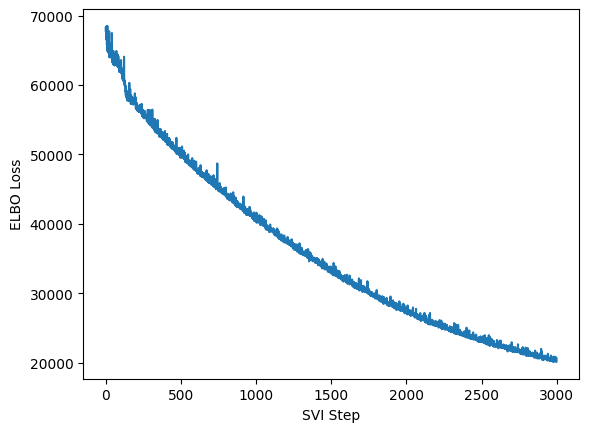

In [6]:
from pyro.infer.autoguide import AutoNormal, AutoDiagonalNormal, AutoContinuous, AutoDelta, AutoMultivariateNormal, AutoLaplaceApproximation, AutoStructured
from pyro.optim import ClippedAdam
from pyro.infer import TraceEnum_ELBO
from pyro.optim import Adam

from torch.nn import LogSoftmax

pyro.clear_param_store()
bnn_cat = BNN_Cont(in_dim=14,first_hid_dim=56,sec_hid_dim=114,thir_hid_dim=114,four_hid_dim=56,out_dim=2,prior_scale=1,bias_scale=10)
# guide = AutoDelta(bnn_cat)
guide = AutoDiagonalNormal(bnn_cat,init_scale=0.1)

num_steps = 3000

init_lr = 0.001
gamma = 0.0001
lrd = gamma ** (1/num_steps)
# optim = ClippedAdam({'lr': init_lr, 'lrd': lrd, "betas": (0.95, 0.999)})
optim = Adam({"lr": 0.001,"betas": (0.95, 0.999)})

svi = SVI(bnn_cat, guide, optim, TraceEnum_ELBO())
losses = []
steps = []

for i in range(num_steps):
    loss = svi.step(x_train,y_train)
    losses.append(loss)
    steps.append(i)
    if i % (num_steps/10) == 0:
        print("[iteration %04d] loss: %.4f" % (i + 1, loss / len(x_train)))

plt.plot(steps,losses)
plt.ylabel("ELBO Loss")
plt.xlabel("SVI Step")
plt.show()

In [7]:
pyro.clear_param_store()
predictive = Predictive(bnn_cat, guide=guide, num_samples=500, return_sites=["obs","_RETURN"]) # confidence scales inversely w/ num_samples, low num_samp -> high confidence

y_train_hot = [[0,1] if j[0] < j[1] else [1,0] for j in y_train]
y_test_hot = [[0,1] if j[0] < j[1] else [1,0] for j in y_test]

pyro.clear_param_store()
train_preds = predictive(x_train)

pyro.clear_param_store()
test_preds = predictive(x_test)

#pyro.clear_param_store()
##bet_train_preds = predictive(bet_train)

pred_performance(train_preds,test_preds,y_train_hot,y_test_hot,categorical=False)

---TRAINING SET---
OBS:
TN, FP, FN, TP
[3398  951 1796 1508]
              precision    recall  f1-score   support

           0       0.65      0.78      0.71      4349
           1       0.61      0.46      0.52      3304

    accuracy                           0.64      7653
   macro avg       0.63      0.62      0.62      7653
weighted avg       0.64      0.64      0.63      7653

RET:
TN, FP, FN, TP
[3401  948 1799 1505]
              precision    recall  f1-score   support

           0       0.65      0.78      0.71      4349
           1       0.61      0.46      0.52      3304

    accuracy                           0.64      7653
   macro avg       0.63      0.62      0.62      7653
weighted avg       0.64      0.64      0.63      7653

---TEST SET---
OBS:
TN, FP, FN, TP
[1139  295  629  488]
              precision    recall  f1-score   support

           0       0.64      0.79      0.71      1434
           1       0.62      0.44      0.51      1117

    accuracy          

In [ ]:
combined[]

In [8]:
obs_train,obs_test,ret_train,ret_test,obs_info,ret_info = make_bets(train_preds,test_preds,y_train_bets,y_test_bets,y_train,y_test,diff_thresh=-0.05,
                                                        diff_cap=0.05,categorical=False,verbose=True,log_probs=True,line_shopping=True)

PREDICTIONS ON 2022-2023 DATA (SEEN IN TRAINING)
Using OBS:
max confidence: 0.82
correct: 1067
guessed: 1835
risked: 8338.212890625
made: 1794.7115478515625
ROI: 0.22

Using RET:
max confidence: 0.62
correct: 1155
guessed: 2038
risked: 5594.27783203125
made: 1103.503173828125
ROI: 0.20

PREDICTIONS ON 2023-2024 DATA (UNSEEN)
Using OBS:
max confidence: 0.80
correct: 351
guessed: 605
risked: 2889.139892578125
made: 575.9344482421875
ROI: 0.20

Using RET:
max confidence: 0.62
correct: 367
guessed: 657
risked: 1943.73291015625
made: 208.93238830566406
ROI: 0.11



In [ ]:
cap, obs_tr, obs_te, ret_tr, ret_te = find_cap(train_preds,test_preds,y_train_bets,y_test_bets,y_train,y_test,line_shopping=True)
plt.plot(cap,obs_tr,label="obs train")
plt.plot(cap,obs_te,label="obs test")
plt.plot(cap,ret_tr,label="ret train")
plt.plot(cap,ret_te,label="ret test")
plt.plot(cap,[0]*len(cap),linestyle=":")
plt.ylabel("ROI")
plt.xlabel("Diff Cap")
plt.legend()
plt.show()